In [6]:
@time using DataFrames, Plots

  7.273675 seconds (1.93 M allocations: 129.885 MiB, 2.20% gc time, 25.62% compilation time: 96% of which was recompilation)


In [9]:
h = 0.5   #step size
a = 0.0   #initial x
b = 1.0;   #final x 

In [18]:
#These functions are different right hand sides for the ODE Y' = f(t,Y)
function f1(t,y)
    return -y^2 
end 

function f2(t,y)
    return (y/4)*(1 - y/20)
end

function f3(t,y)
    -y + 2*cos(t)
end 

function f4(t,y)
    y - 2*sin(t)
end 

f4 (generic function with 1 method)

In [19]:
#Y_i(t) is the true solution of the ODE y' = fᵢ(t,y) for i=1,2,3,4 with the given initial value

In [35]:
function Y1(t)
    return 1/(1 + t)
end

function Y2(t)
    return 20/(1 + 19*exp(-t/4))
end 

function Y3(t)
    return cos(t) + sin(t)
end

Y3 (generic function with 1 method)

In [105]:
function Euler(f, y0, t0, tf, h)

    #Solves the non-autonomous IVP y'(t) = f(t, y(t)), y(0) = y0 on the interval [t0, tf]
    
    #f:  The right-hand side of the ODE. Must have two arguments, the first being time. 
    #y0: The initial value of the function, i.e. the value y(0)
    #t0: The initial time 
    #tf: The time up to which to integrate
    #h:  The step size 
    
    #t values at which to compute the solution; t = [t0, t0 + h, t0 + 2h,..., t0 + floor((tf - t0)/h)*h]
    t = collect(t0:h:tf)     
    
    #Array to store the numerical solution 
    y = zeros(length(t)) 
    
    #Input the initial condition 
    y[1] = y0  
    
    #Euler's method 
    for n=2:length(t)
        y[n] = y[n-1] + h*f(t,y[n-1])
    end 
    
    return t,y
    
end

Euler (generic function with 1 method)

Coding notes:
- Collect and StepRangeLen objects (the latter is not mutable; must use collect)
- Other ways to initialize arrays

In [126]:
#Solve f1 on the interval [0,5] with y₀ = 1 
h = 0.125
sol1 = Euler(f1, 1.0, 0.0, 5.0, h)
t,y1_num = sol1
y1_true = Y1.(t);

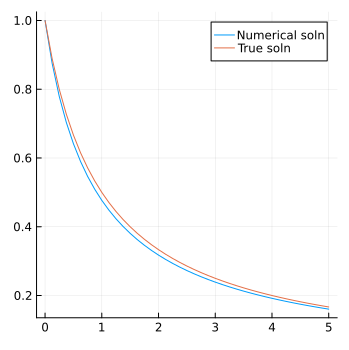

In [127]:
plot(t,y1_num, label = "Numerical soln")
plot!(t,y1_true, label = "True soln")
plot!(size = (350,350))

In [39]:
a = 0.5:0.1:0.8
print(a)

0.5:0.1:0.8

In [48]:
for i in a
    print(i, " ")
end 

0.5 0.6 0.7 0.8 

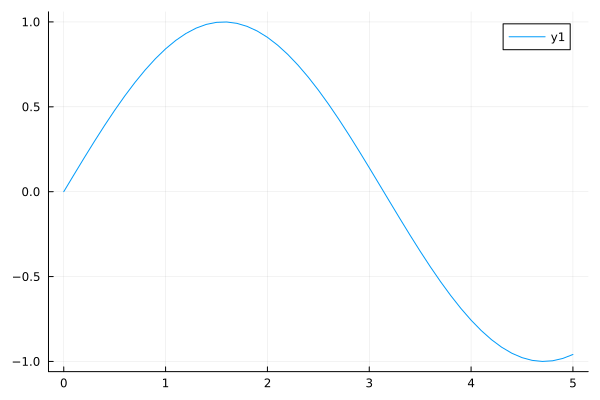

In [108]:
x = collect(0:0.1:5)
y = sin.(x)
plot(x,y)